# ============================================================
# MODELO HÍBRIDO — ELÉCTRICO + VIBRACIÓN
# ============================================================


In [1]:

# ============================================================
# 0. INSTALACIÓN
# ============================================================

!pip install h2o optuna optuna-dashboard plotly seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 307.4 kB/s  0:14:07 eta 0:00:010:00:22
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 322.9 kB/s  0:00:25323.3 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 312.9 kB/s  0:00:31a 0:00:010:00:02:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 316.5 kB/s  0:00:31a 0:00:010:00:02:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 314.7 kB/s  0:00:154.1 kB/s eta 0:00:01:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 298.9 kB/s  0:00:04312.0 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 305.2 kB/s  0:00:235.0 kB/s eta 0:00:01:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 343.2 kB/s  0:00:096.6 kB/s eta 0:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.8/660.8 kB 412.6 kB/s  0:00:01451.9 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 310.5 kB/s  0:00:02334.9 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import h2o
from h2o.estimators import H2OExtendedIsolationForestEstimator
import optuna
from optuna.trial import TrialState
import optuna.visualization as vis
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "browser"

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# 2. CONFIGURACIÓN
# ============================================================


RUTA_FEATURES   = "features"
CSV_INDEX       = "Motor_DB/index/master_index.csv"
RUTA_RESULTADOS = "resultados_hibrido_2"
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

N_TRIALS = 500
SEED     = 42

N_FEATURES  = 39   # 24 + 15
study_name_elec = "EIF_electrico_v2_39features"
study_name_vib  = "EIF_vibracion_v2_39features"


In [4]:
# ============================================================
# SEPARAR COLUMNAS
# ============================================================
cols_todas      = pd.read_csv("features/train/sano_train.csv", nrows=0).columns.tolist()
cols_electricas = [c for c in cols_todas if c.startswith(("u_", "v_", "w_"))]
cols_vibracion  = [c for c in cols_todas if not c.startswith(("u_", "v_", "w_"))]

print(f"Eléctricas : {len(cols_electricas)} columnas → {cols_electricas}")
print(f"Vibración  : {len(cols_vibracion)} columnas → {cols_vibracion}")

EXT_MAX_ELEC = len(cols_electricas) - 1  # 23  (8 features × 3 señales = 24 → max 23)
EXT_MAX_VIB  = len(cols_vibracion)  - 1  # 14  (3 features × 5 señales = 15 → max 14)

Eléctricas : 24 columnas → ['u_katz', 'u_perm_entropy', 'u_kurtosis', 'u_espectro_DC', 'u_espectro_50Hz', 'u_espectro_100Hz', 'u_espectro_150Hz', 'u_espectro_200Hz', 'v_katz', 'v_perm_entropy', 'v_kurtosis', 'v_espectro_DC', 'v_espectro_50Hz', 'v_espectro_100Hz', 'v_espectro_150Hz', 'v_espectro_200Hz', 'w_katz', 'w_perm_entropy', 'w_kurtosis', 'w_espectro_DC', 'w_espectro_50Hz', 'w_espectro_100Hz', 'w_espectro_150Hz', 'w_espectro_200Hz']
Vibración  : 15 columnas → ['front_DE_Y_katz', 'front_DE_Y_perm_entropy', 'front_DE_Y_kurtosis', 'front_DE_Z_katz', 'front_DE_Z_perm_entropy', 'front_DE_Z_kurtosis', 'rear_NDE_Y_katz', 'rear_NDE_Y_perm_entropy', 'rear_NDE_Y_kurtosis', 'rear_NDE_Z_katz', 'rear_NDE_Z_perm_entropy', 'rear_NDE_Z_kurtosis', 'housing_katz', 'housing_perm_entropy', 'housing_kurtosis']


In [5]:
# ============================================================
# 3. INICIALIZAR H2O
# ============================================================

h2o.init(
    nthreads=-1,       # usa todos los cores disponibles
    max_mem_size="10G"  # ajusta según tu RAM
)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "26.0.1" 2026-04-21; OpenJDK Runtime Environment (build 26.0.1); OpenJDK 64-Bit Server VM (build 26.0.1, mixed mode, sharing)
  Starting server from /home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpjjvywa5l
  JVM stdout: /tmp/tmpjjvywa5l/h2o_arielingm_started_from_python.out
  JVM stderr: /tmp/tmpjjvywa5l/h2o_arielingm_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,3 days
H2O_cluster_name:,H2O_from_python_arielingm_1k9izl
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,9.98 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [6]:
# ============================================================
# 4. CARGAR DATOS
# ============================================================

print("Cargando datos...\n")

index        = pd.read_csv(CSV_INDEX)
carpeta_test = os.path.join(RUTA_FEATURES, "test")

# Cargar frames completos
train_full    = h2o.import_file(os.path.join(RUTA_FEATURES, "train", "sano_train.csv"))
val_full      = h2o.import_file(os.path.join(RUTA_FEATURES, "val",   "sano.csv"))
test_sano_full = h2o.import_file(os.path.join(RUTA_FEATURES, "test",  "sano.csv"))

fallos_full = {}
for archivo in sorted(os.listdir(carpeta_test)):
    if archivo.endswith(".csv") and archivo != "sano.csv":
        nombre = archivo.replace(".csv", "")
        fallos_full[nombre] = h2o.import_file(os.path.join(carpeta_test, archivo))

# Seleccionar columnas por modelo
train_elec     = train_full[cols_electricas]
train_vib      = train_full[cols_vibracion]

val_elec       = val_full[cols_electricas]
val_vib        = val_full[cols_vibracion]

test_sano_elec = test_sano_full[cols_electricas]
test_sano_vib  = test_sano_full[cols_vibracion]

fallos_elec = {n: f[cols_electricas] for n, f in fallos_full.items()}
fallos_vib  = {n: f[cols_vibracion]  for n, f in fallos_full.items()}

print(f"\nTrain eléctrico : {train_elec.shape}")
print(f"Train vibración : {train_vib.shape}")

Cargando datos...

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |██████████████

In [7]:
# ============================================================
# 5. FUNCIONES AUXILIARES
# ============================================================

def agregar_por_experimento_variable(scores_array, n_archivos):
    n = len(scores_array)
    ventanas_por_exp = n // n_archivos
    medianas = []
    for i in range(0, n, ventanas_por_exp):
        grupo = scores_array[i:i + ventanas_por_exp]
        if len(grupo) > 0:
            medianas.append(np.median(grupo))
    return np.array(medianas)

def calcular_umbral(model, train_frame, val_frame, ventanas=100):
    s_train = model.predict(train_frame)["anomaly_score"].as_data_frame().values.flatten()
    s_val   = model.predict(val_frame)["anomaly_score"].as_data_frame().values.flatten()
    med_train = agregar_por_experimento_variable(s_train, len(s_train)//ventanas)
    med_val   = agregar_por_experimento_variable(s_val,   len(s_val)//ventanas)
    todos = np.concatenate([med_train, med_val])
    return np.mean(todos) + 3 * np.std(todos), np.mean(todos), np.std(todos)

In [8]:
# ============================================================
# OPTUNA — MODELO ELÉCTRICO
# ============================================================

print("\n" + "="*60)
print("OPTIMIZANDO MODELO ELÉCTRICO")
print("="*60)

def objective_elec(trial):
    ntrees          = trial.suggest_int("ntrees",          100, 800)
    sample_size     = trial.suggest_int("sample_size",     256, 1060, step=64)
    extension_level = trial.suggest_int("extension_level", 0,   EXT_MAX_ELEC)

    model = H2OExtendedIsolationForestEstimator(
        ntrees=ntrees, sample_size=sample_size,
        extension_level=extension_level, seed=SEED
    )
    try:
        model.train(training_frame=train_elec)
    except Exception:
        raise optuna.exceptions.TrialPruned()

    s_train = model.predict(train_elec)["anomaly_score"].as_data_frame().values.flatten()
    s_val   = model.predict(val_elec)["anomaly_score"].as_data_frame().values.flatten()
    med_t   = agregar_por_experimento_variable(s_train, 30)
    med_v   = agregar_por_experimento_variable(s_val,    6)
    todos   = np.concatenate([med_t, med_v])
    umbral  = np.mean(todos) + 3 * np.std(todos)

    trial.set_user_attr("umbral", round(float(umbral), 6))
    return umbral

study_elec = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///resultados_hibrido/optuna_elec.db",
    study_name=study_name_elec, load_if_exists=True
)
study_elec.optimize(objective_elec, n_trials=N_TRIALS, show_progress_bar=True)


OPTIMIZANDO MODELO ELÉCTRICO


[I 2026-05-25 16:18:57,825] A new study created in RDB with name: EIF_electrico_v2_39features
  0%|          | 0/500 [00:00<?, ?it/s]

extendedisolationforest Model Build progress: |

/tmp/ipykernel_18947/1284754388.py:11: UserWarning: The distribution is specified by [256, 1060] and step=64, but the range is not divisible by `step`. It will be replaced with [256, 1024].
  sample_size     = trial.suggest_int("sample_size",     256, 1060, step=64)
/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/estimators/estimator_base.py:192: RuntimeWarning: Dropping bad and constant columns: [v_espectro_50Hz, u_espectro_150Hz, v_espectro_150Hz, w_espectro_150Hz, w_espectro_50Hz, u_espectro_50Hz]
  warnings.warn(mesg["message"], RuntimeWarning)


██████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

...

extendedisolationforest Model Build progress: | (failed)
[I 2026-05-25 16:43:55,769] Trial 497 pruned. 
extendedisolationforest Model Build progress: |██████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

Best trial: 231. Best value: 0.409118: 100%|█████████▉| 499/500 [25:01<00:02,  2.73s/it]

███████████████████████████████████| (done) 100%
[I 2026-05-25 16:43:59,727] Trial 498 finished with value: 0.4212345477017264 and parameters: {'ntrees': 386, 'sample_size': 960, 'extension_level': 17}. Best is trial 231 with value: 0.4091179898765638.
extendedisolationforest Model Build progress: |██████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

Best trial: 231. Best value: 0.409118: 100%|██████████| 500/500 [25:06<00:00,  3.01s/it]

███████████████████████████████████| (done) 100%
[I 2026-05-25 16:44:04,314] Trial 499 finished with value: 0.40979257397725033 and parameters: {'ntrees': 411, 'sample_size': 1024, 'extension_level': 17}. Best is trial 231 with value: 0.4091179898765638.


In [9]:
# ============================================================
# OPTUNA — MODELO VIBRACIÓN
# ============================================================
print("\n" + "="*60)
print("OPTIMIZANDO MODELO VIBRACIÓN")
print("="*60)

def objective_vib(trial):
    ntrees          = trial.suggest_int("ntrees",          100, 800)
    sample_size     = trial.suggest_int("sample_size",     256, 1060, step=64)
    extension_level = trial.suggest_int("extension_level", 0,   EXT_MAX_VIB)

    model = H2OExtendedIsolationForestEstimator(
        ntrees=ntrees, sample_size=sample_size,
        extension_level=extension_level, seed=SEED
    )
    try:
        model.train(training_frame=train_vib)
    except Exception:
        raise optuna.exceptions.TrialPruned()

    s_train = model.predict(train_vib)["anomaly_score"].as_data_frame().values.flatten()
    s_val   = model.predict(val_vib)["anomaly_score"].as_data_frame().values.flatten()
    med_t   = agregar_por_experimento_variable(s_train, 30)
    med_v   = agregar_por_experimento_variable(s_val,    6)
    todos   = np.concatenate([med_t, med_v])
    umbral  = np.mean(todos) + 3 * np.std(todos)

    trial.set_user_attr("umbral", round(float(umbral), 6))
    return umbral

study_vib = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///resultados_hibrido/optuna_vib.db",
    study_name=study_name_vib, load_if_exists=True
)
study_vib.optimize(objective_vib, n_trials=N_TRIALS, show_progress_bar=True)

[I 2026-05-25 17:43:39,109] A new study created in RDB with name: EIF_vibracion_v2_39features



OPTIMIZANDO MODELO VIBRACIÓN


  0%|          | 0/500 [00:00<?, ?it/s]

extendedisolationforest Model Build progress: |

/tmp/ipykernel_18947/119468795.py:10: UserWarning: The distribution is specified by [256, 1060] and step=64, but the range is not divisible by `step`. It will be replaced with [256, 1024].
  sample_size     = trial.suggest_int("sample_size",     256, 1060, step=64)


...

███████████████████████████████████| (done) 100%
[I 2026-05-25 18:00:40,447] Trial 497 finished with value: 0.3852644663224909 and parameters: {'ntrees': 125, 'sample_size': 1024, 'extension_level': 10}. Best is trial 92 with value: 0.3693270120589013.
extendedisolationforest Model Build progress: |██████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

Best trial: 92. Best value: 0.369327: 100%|█████████▉| 499/500 [17:05<00:02,  2.28s/it]

███████████████████████████████████| (done) 100%
[I 2026-05-25 18:00:44,440] Trial 498 finished with value: 0.37737586546319857 and parameters: {'ntrees': 329, 'sample_size': 1024, 'extension_level': 13}. Best is trial 92 with value: 0.3693270120589013.
extendedisolationforest Model Build progress: |██████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

Best trial: 92. Best value: 0.369327: 100%|██████████| 500/500 [17:06<00:00,  2.05s/it]

███████████████████████████████████| (done) 100%
[I 2026-05-25 18:00:45,748] Trial 499 finished with value: 0.3710965899263927 and parameters: {'ntrees': 100, 'sample_size': 1024, 'extension_level': 14}. Best is trial 92 with value: 0.3693270120589013.


In [14]:



# ============================================================
# MODELOS FINALES
# ============================================================

study_elec = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///resultados_hibrido/optuna_elec.db",
    study_name="EIF_electrico", load_if_exists=True
)
study_vib = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///resultados_hibrido/optuna_vib.db",
    study_name="EIF_vibracion", load_if_exists=True
)

modelo_vib = None
trials_ordenados = sorted(study_vib.trials, key=lambda t: t.value if t.value else float('inf'))

for trial in trials_ordenados:
    if trial.value is None:
        continue
    try:
        modelo_vib = H2OExtendedIsolationForestEstimator(
            ntrees          = trial.params["ntrees"],
            sample_size     = trial.params["sample_size"],
            extension_level = trial.params["extension_level"],
            seed            = SEED
        )
        modelo_vib.train(training_frame=train_vib)
        print(f"  Modelo vibración entrenado con trial {trial.number}: "
              f"ntrees={trial.params['ntrees']}, "
              f"sample_size={trial.params['sample_size']}, "
              f"extension_level={trial.params['extension_level']}")
        best_vib = trial
        break
    except Exception:
        print(f"  Trial {trial.number} falló por memoria, probando siguiente...")
        continue

if modelo_vib is None:
    print("ERROR: ningún trial funcionó")

# Umbrales finales
umbral_elec, media_e, std_e = calcular_umbral(modelo_elec, train_elec, val_elec)
umbral_vib,  media_v, std_v = calcular_umbral(modelo_vib,  train_vib,  val_vib)

print(f"\nUmbral eléctrico: {umbral_elec:.6f} (media={media_e:.4f}, std={std_e:.4f})")
print(f"Umbral vibración: {umbral_vib:.6f}  (media={media_v:.4f}, std={std_v:.4f})")

# Guardar hiperparámetros
with open(os.path.join(RUTA_RESULTADOS, "hiperparametros.json"), "w") as f:
    json.dump({
        "electrico": best_elec.params,
        "vibracion": best_vib.params,
        "umbral_elec": umbral_elec,
        "umbral_vib":  umbral_vib
    }, f, indent=2)

[I 2026-05-25 18:10:47,883] Using an existing study with name 'EIF_electrico' instead of creating a new one.
[I 2026-05-25 18:10:47,937] Using an existing study with name 'EIF_vibracion' instead of creating a new one.


extendedisolationforest Model Build progress: | (failed)
  Trial 163 falló por memoria, probando siguiente...
extendedisolationforest Model Build progress: | (failed)
  Trial 681 falló por memoria, probando siguiente...
extendedisolationforest Model Build progress: | (failed)
  Trial 695 falló por memoria, probando siguiente...
extendedisolationforest Model Build progress: | (failed)
  Trial 607 falló por memoria, probando siguiente...
extendedisolationforest Model Build progress: | (failed)
  Trial 465 falló por memoria, probando siguiente...
extendedisolationforest Model Build progress: | (failed)
  Trial 601 falló por memoria, probando siguiente...
extendedisolationforest Model Build progress: | (failed)
  Trial 508 falló por memoria, probando siguiente...
extendedisolationforest Model Build progress: | (failed)
  Trial 757 falló por memoria, probando siguiente...
extendedisolationforest Model Build progress: | (failed)
  Trial 835 falló por memoria, probando siguiente...
extendedis

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%

Umbral eléctrico: 0.408742 (media=0.3578, std=0.0170)
Umbral vibración: 0.376707  (media=0.3430, std=0.0112)


In [15]:
# ============================================================
# 10. EVALUACIÓN POR EXPERIMENTO
# ============================================================

print("\n" + "="*60)
print("EVALUACIÓN POR EXPERIMENTO")
print("="*60)

def evaluar(model_e, model_v, umbral_e, umbral_v, frame_e, frame_v, n_archivos, nombre):
    s_e = model_e.predict(frame_e)["anomaly_score"].as_data_frame().values.flatten()
    s_v = model_v.predict(frame_v)["anomaly_score"].as_data_frame().values.flatten()

    med_e = agregar_por_experimento_variable(s_e, n_archivos)
    med_v = agregar_por_experimento_variable(s_v, n_archivos)

    det_e    = med_e > umbral_e
    det_v    = med_v > umbral_v
    det_comb = det_e | det_v  # OR lógico

    return {
        "grupo":          nombre,
        "n_exp":          len(med_e),
        "det_elec_%":     round(np.mean(det_e)    * 100, 1),
        "det_vib_%":      round(np.mean(det_v)    * 100, 1),
        "det_combinado_%": round(np.mean(det_comb) * 100, 1),
        "med_e": med_e,
        "med_v": med_v,
    }

resultados    = []
datos_box_e   = []
datos_box_v   = []
datos_box_c   = []

# Sano test
n_sano = len(index[(index["Split"] == "test") & (index["Maquina"] == "h")])
res = evaluar(modelo_elec, modelo_vib, umbral_elec, umbral_vib,
              test_sano_elec, test_sano_vib, n_sano, "sano_test")
resultados.append(res)

for m in res["med_e"]: datos_box_e.append({"grupo": "sano_test", "mediana": m})
for m in res["med_v"]: datos_box_v.append({"grupo": "sano_test", "mediana": m})
for m in (res["med_e"] + res["med_v"]) / 2:
    datos_box_c.append({"grupo": "sano_test", "mediana": m})

print(f"\n  sano_test → elec: {res['det_elec_%']}% | "
      f"vib: {res['det_vib_%']}% | combinado: {res['det_combinado_%']}%  ← idealmente 0%")

# Fallos
print()
for nombre in sorted(fallos_elec.keys()):
    n_arch = len(index[(index["Split"] == "test") & (index["Fallo"] == nombre)])
    res = evaluar(modelo_elec, modelo_vib, umbral_elec, umbral_vib,
                  fallos_elec[nombre], fallos_vib[nombre], n_arch, nombre)
    resultados.append(res)

    for m in res["med_e"]: datos_box_e.append({"grupo": nombre, "mediana": m})
    for m in res["med_v"]: datos_box_v.append({"grupo": nombre, "mediana": m})
    for m in (res["med_e"] + res["med_v"]) / 2:
        datos_box_c.append({"grupo": nombre, "mediana": m})

    print(f"  {nombre:<50} "
          f"elec: {res['det_elec_%']:>5.1f}% | "
          f"vib: {res['det_vib_%']:>5.1f}% | "
          f"combinado: {res['det_combinado_%']:>5.1f}%")

# Guardar CSV
df_res = pd.DataFrame([{k: v for k, v in r.items()
                         if k not in ["med_e", "med_v"]}
                        for r in resultados])
df_res.to_csv(os.path.join(RUTA_RESULTADOS, "resultados_hibrido.csv"), index=False)



EVALUACIÓN POR EXPERIMENTO
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%

  sano_test → elec: 62.5% | vib: 37.5% | combinado: 62.5%  ← idealmente 0%

extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_barra_rota_1_DTC_S1200                       elec:   0.0% | vib:  75.0% | combinado:  75.0%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

...

███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_S1500               elec:   0.0% | vib:   0.0% | combinado:   0.0%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_S900                elec:   0.0% | vib:  33.3% | combinado:  33.3%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_STrap               elec:   0.0% | vib:   0.0% | combinado:   0.0%


/tmp/ipykernel_18947/3186253264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box[df_box["grupo"].isin(orden)],


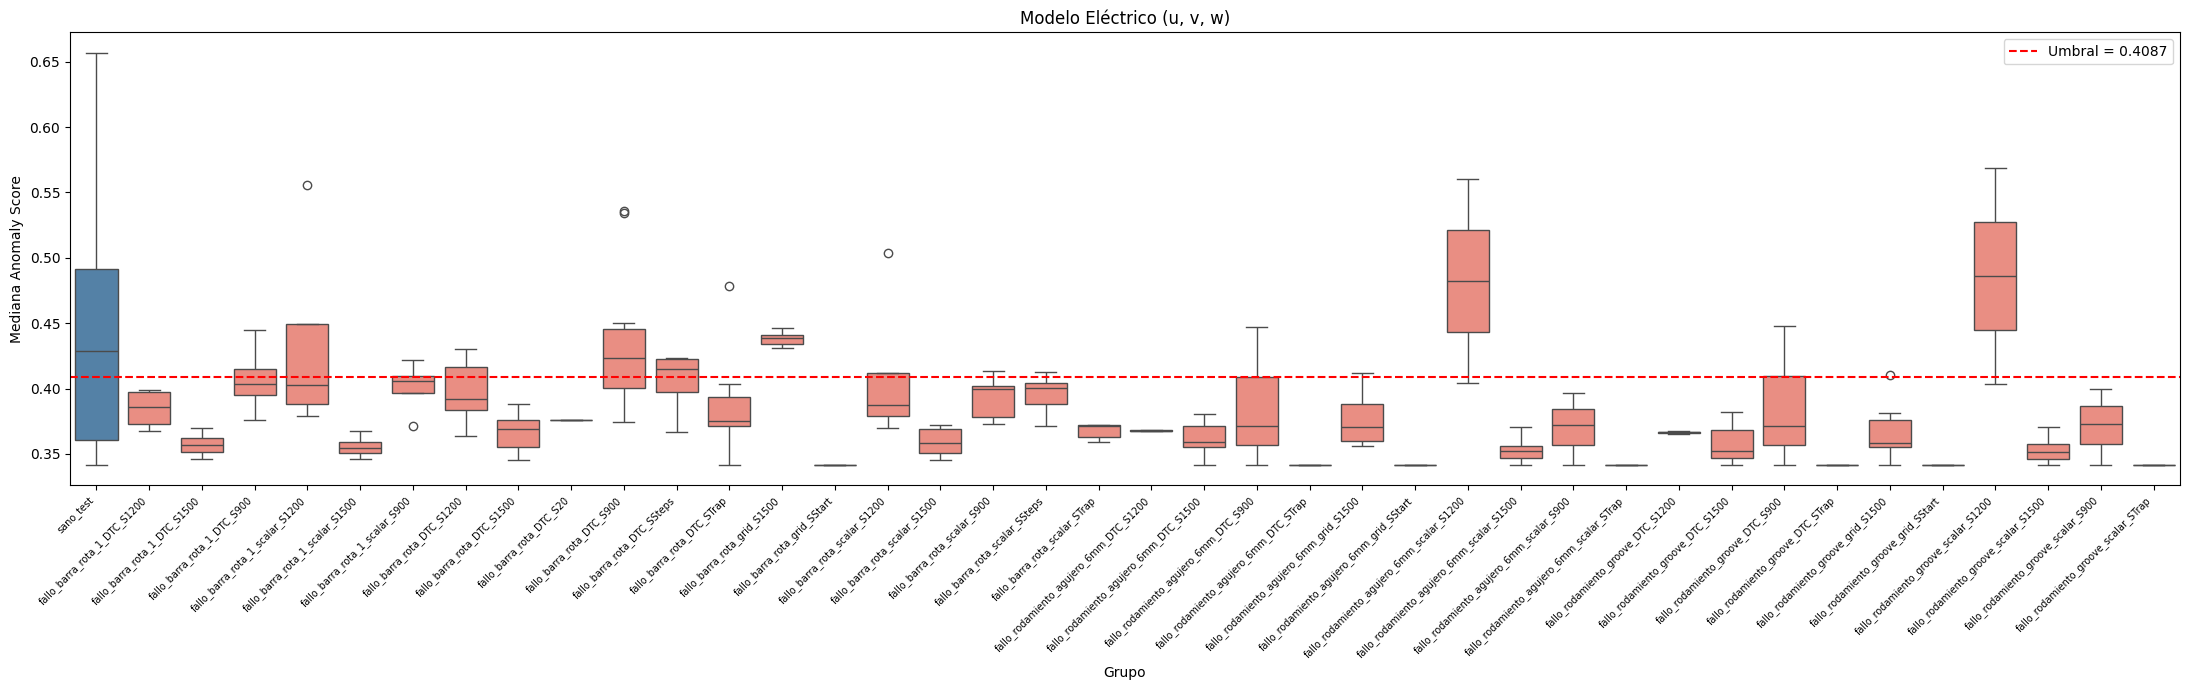

/tmp/ipykernel_18947/3186253264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box[df_box["grupo"].isin(orden)],


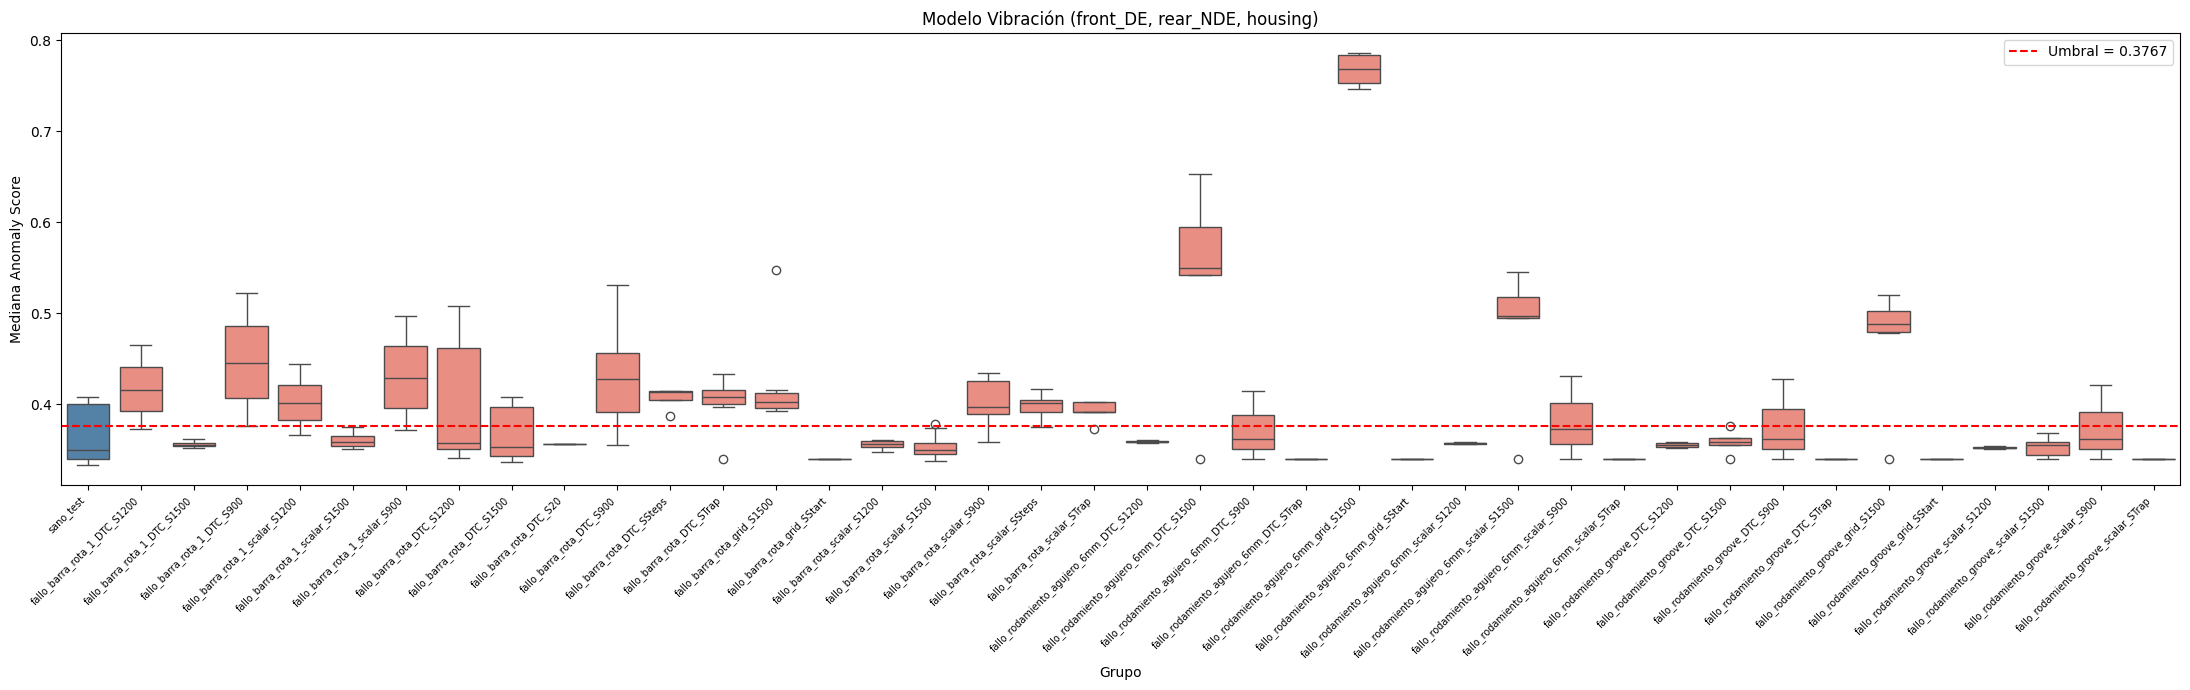

/tmp/ipykernel_18947/3186253264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box[df_box["grupo"].isin(orden)],


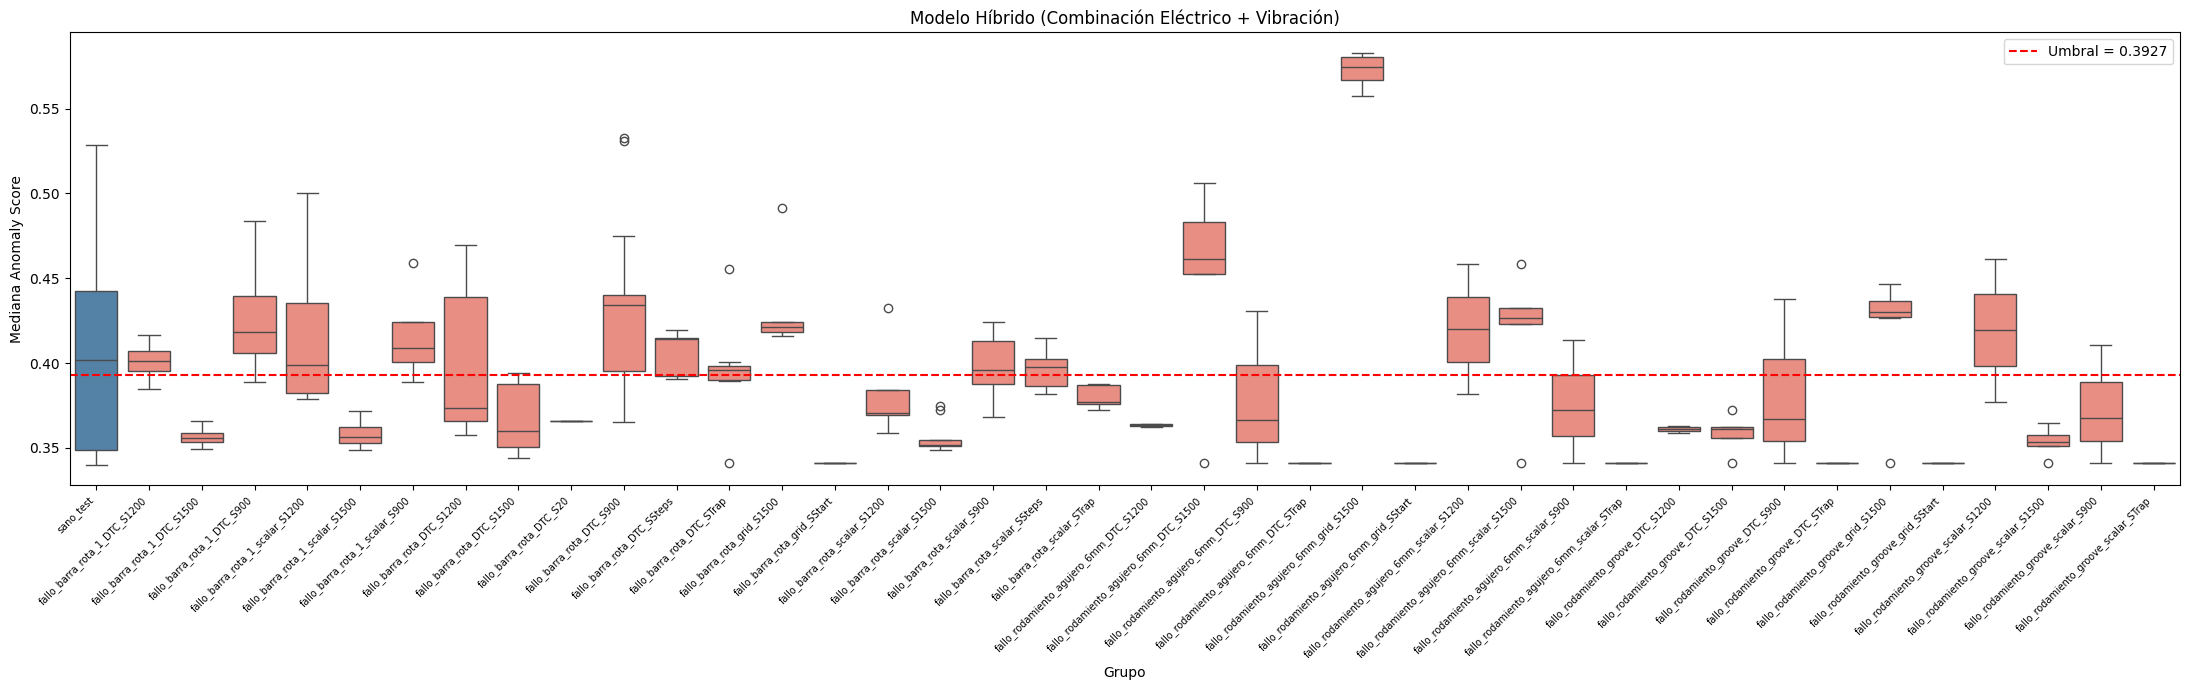


✅ Todo completado.
Umbral eléctrico : 0.408742
Umbral vibración : 0.376707


In [16]:

# ============================================================
# 11. BOXPLOT ESTILO PAPER
# ============================================================

orden = ["sano_test"] + sorted([n for n in fallos_elec.keys()])
colores = {g: "steelblue" if "sano" in g else "salmon" for g in orden}

def hacer_boxplot(datos, umbral, titulo, filename):
    df_box = pd.DataFrame(datos)
    plt.figure(figsize=(22, 7))
    sns.boxplot(data=df_box[df_box["grupo"].isin(orden)],
                x="grupo", y="mediana", order=orden, palette=colores)
    plt.axhline(y=umbral, color="red", linestyle="--", linewidth=1.5,
                label=f"Umbral = {umbral:.4f}")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.title(titulo)
    plt.xlabel("Grupo")
    plt.ylabel("Mediana Anomaly Score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RUTA_RESULTADOS, filename), dpi=150)
    plt.show()

# Gráfica 1 — Solo eléctrico
hacer_boxplot(datos_box_e, umbral_elec,
              "Modelo Eléctrico (u, v, w)",
              "boxplot_electrico.png")

# Gráfica 2 — Solo vibración
hacer_boxplot(datos_box_v, umbral_vib,
              "Modelo Vibración (front_DE, rear_NDE, housing)",
              "boxplot_vibracion.png")

# Gráfica 3 — Combinado (promedio scores)
umbral_comb = (umbral_elec + umbral_vib) / 2
hacer_boxplot(datos_box_c, umbral_comb,
              "Modelo Híbrido (Combinación Eléctrico + Vibración)",
              "boxplot_hibrido.png")

print("\n✅ Todo completado.")
print(f"Umbral eléctrico : {umbral_elec:.6f}")
print(f"Umbral vibración : {umbral_vib:.6f}")